In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

# My Model

In [80]:
class myKMeans:

    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None


    def fit_predict(self, X_train):
        random_index = random.sample(range(0, X_train.shape[0]), self.n_clusters)
        self.centroids = X_train[random_index]

        for i in range(self.max_iter):
            # assign cluseters
            cluster_group = self._assign_cluster(X_train)
            
            # move centroids
            old_centroid = self.centroids
            self.centroids = self._move_centroid(X_train, cluster_group)
            
            # finish
            if np.allclose(old_centroid , self.centroids):
                break

        return cluster_group

    def _assign_cluster(self, X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.linalg.norm(row - centroid))
            min_dist = min(distances)
            index_pos = distances.index(min_dist)
            cluster_group.append(index_pos)
            distances.clear()
                

        return np.array(cluster_group)

    def _move_centroid(self, X, cluster_group):
        new_centroids = []
        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return new_centroids

    
        

# Dataset

In [81]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=3, random_state=0)


In [82]:
X

array([[ 0.06344785,  5.42080362],
       [ 1.32967014, -0.4857003 ],
       [ 1.7373078 ,  4.42546234],
       [-1.61283478,  3.1121752 ],
       [-1.74644504,  1.83384564],
       [-1.51827611,  3.44488647],
       [ 0.02458305,  2.96215652],
       [-0.24916544,  5.1481503 ],
       [-2.48740839,  2.1247649 ],
       [ 0.21196866,  3.91227665],
       [ 0.11898772,  1.08644226],
       [ 2.6225578 ,  0.67498856],
       [ 3.70340245,  1.06189142],
       [ 1.42013331,  4.63746165],
       [ 1.78753398, -0.23034767],
       [-1.74385358,  3.36327551],
       [ 1.37861172,  3.61897724],
       [ 1.35269561,  3.20438654],
       [-1.18799989,  4.93892582],
       [ 0.86640826,  0.39084731],
       [-1.96609354,  3.09922069],
       [ 1.28933778,  3.44969159],
       [ 0.89791226,  0.58537141],
       [ 0.08080352,  4.69068983],
       [-3.20812223,  2.0289109 ],
       [-2.45706052,  2.73929317],
       [-0.07228289,  2.88376939],
       [-2.5568393 ,  2.5679389 ],
       [ 2.63378902,

In [83]:
y

array([0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 1, 1, 1, 0, 1, 2, 0, 0, 2, 1, 2, 0,
       1, 0, 2, 2, 0, 2, 1, 1, 2, 0, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 0, 1,
       1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 0, 2, 1, 2,
       0, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2,
       0, 0, 2, 1, 2, 0, 1, 1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 0, 2, 0, 1, 1,
       0, 2, 0, 0, 2, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2,
       0, 2, 2, 1, 2, 0, 2, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 1, 0, 2, 0, 1,
       2, 2, 1, 1, 0, 1, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 2, 1, 1, 1,
       0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 1, 1, 2, 0, 1, 2,
       0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 1,
       0, 1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2,
       2, 2, 2, 1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 2, 0, 0, 2, 0, 2, 2,
       0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 1, 2, 1,
       2, 2, 1, 1, 2, 2, 2, 1, 0, 0, 2, 1, 0, 2])

# Using MyModel

In [84]:
myKM = myKMeans(n_clusters=3)
my_y_means = myKM.fit_predict(X)

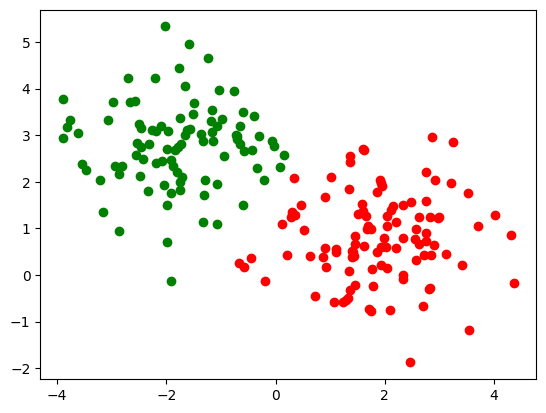

In [85]:
plt.scatter(X[my_y_means == 0,0], X[my_y_means == 0,1], color='red')
plt.scatter(X[my_y_means == 1,0], X[my_y_means == 1,1], color='green')

# Using SKLearn

In [86]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(df)
    wcss.append(kmeans.inertia_)

In [87]:
wcss

[781.3706,
 179.05358288770057,
 87.22062785114048,
 67.66291891891893,
 51.16850000000001,
 45.95979710144928,
 41.36199017421908,
 34.35130598976187,
 29.500248721737503,
 28.382941840767927]

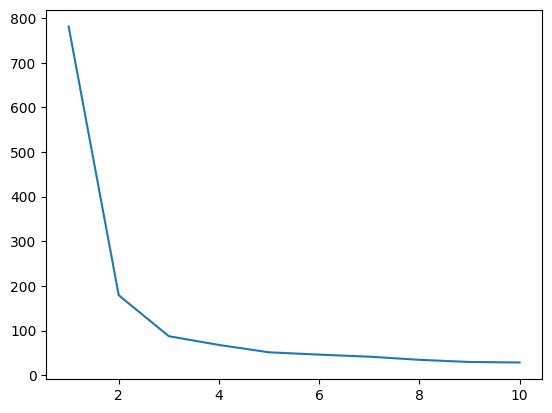

In [88]:
plt.plot(range(1, 11), wcss)

In [91]:
kmeans = KMeans(n_clusters=2)
y_means = kmeans.fit_predict(X)

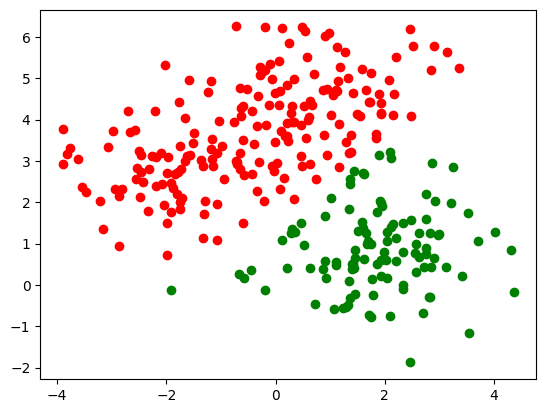

In [92]:
plt.scatter(X[y_means == 0,0], X[y_means == 0,1], color='red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1], color='green')